# Reward-Style Ablation — Training Analysis

Three reward structures at 2M steps each:  
- **hybrid**: $A \times p \times l \times e + div + comp$
- **additive**: $A + 5p + 5l + 5e + div + comp$
- **multiplicative**: $A \times p \times l \times e \times (1+div/5) \times (1+comp/5)$

All three normalized to same theoretical max (HYBRID_MAX = 26.3).

In [1]:
import re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── style ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 140,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.5,
})

# ── colour palette ─────────────────────────────────────
COLORS = {
    "hybrid":         "#FF9500",
    "additive":       "#8E8E93",
    "multiplicative": "#5856D6",
}
LABELS = {
    "hybrid":         "hybrid",
    "additive":       "additive",
    "multiplicative": "multiplicative",
}

# ── data loading ───────────────────────────────────────
def load_run(run_dir: str, label: str) -> pd.DataFrame:
    path = Path(f"runs/{run_dir}/progress.csv")
    if not path.exists():
        raise FileNotFoundError(str(path))
    df = pd.read_csv(path)
    df["style"] = label
    return df

# Three 2M ablation runs
RUNS = {
    "hybrid":         "ppo_2M_v2",
    "additive":       "pilot_additive_2M",
    "multiplicative": "pilot_mult",
}

dfs = {style: load_run(path, style) for style, path in RUNS.items()}
df_all = pd.concat(dfs.values(), ignore_index=True)

# Use time/total_timesteps as x-axis (in thousands)
for style in RUNS:
    dfs[style]["k_steps"] = dfs[style]["time/total_timesteps"] / 1000

print(f"Loaded {len(RUNS)} runs, {len(df_all)} total rows")
for style, df in dfs.items():
    print(f"  {style:>14}: {len(df):>4} rows,  steps range {df['time/total_timesteps'].min():,.0f} → {df['time/total_timesteps'].max():,.0f}")

Loaded 3 runs, 1286 total rows
          hybrid:  396 rows,  steps range 10,000 → 2,007,040
        additive:  445 rows,  steps range 8,192 → 2,007,040
  multiplicative:  445 rows,  steps range 8,192 → 2,007,040


In [2]:
# ── smoothing helper ───────────────────────────────────
def smooth(y: np.ndarray, window: int = 20) -> np.ndarray:
    """Rolling mean on non-NaN values; drops NaN, smooths, then reindexes."""
    mask = ~np.isnan(y)
    y_clean = y[mask]
    if len(y_clean) < window:
        return y
    pad = window // 2
    y_pad = np.concatenate([y_clean[pad:0:-1], y_clean, y_clean[-2:-pad-2:-1]])
    kernel = np.ones(window) / window
    y_sm = np.convolve(y_pad, kernel, mode="valid")
    # Map back to original indices
    out = np.full_like(y, np.nan, dtype=float)
    out[mask] = y_sm[:len(y_clean)]
    return out


def plot_metric(ax, metric: str, title: str, ylabel: str,
                ylim: tuple[float, float] | None = None,
                smooth_window: int = 12,
                legend: bool = True):
    """Plot one metric across all three reward styles.

    Handles sparse metrics (e.g. eval/mean_reward logged only at eval_freq)
    by forward-filling NaN gaps before smoothing, so the curve never breaks.
    """
    for style in ["additive", "multiplicative", "hybrid"]:
        df = dfs[style]
        if metric not in df.columns:
            continue
        x = df["k_steps"].values
        y_raw = df[metric].values

        # Forward-fill sparse metrics so smoothing doesn't break on NaN
        y_filled = pd.Series(y_raw).ffill().values

        y_smooth = smooth(y_filled, smooth_window)
        mask = ~np.isnan(y_smooth)
        ax.plot(x[mask], y_smooth[mask], color=COLORS[style], lw=1.8,
                label=LABELS[style], zorder=3)

        # Raw dots at actual measurement points (not interpolated)
        raw_mask = ~np.isnan(y_raw)
        ax.plot(x[raw_mask], y_raw[raw_mask], color=COLORS[style],
                lw=0, marker=".", ms=1.2, alpha=0.25, zorder=1)

    ax.set_title(title, weight="bold", pad=8)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Timesteps (k)")
    if ylim:
        ax.set_ylim(*ylim)
    if legend:
        ax.legend(frameon=True, fancybox=True, framealpha=0.85,
                  edgecolor="#ddd", loc="best")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

### Legacy data for §2 / §5 / §6 (run once, cached)

§2 (radar), §5 (spatial), §6 (sequential) read `radar_metrics.json` and
`behavior_data.json`. This cell regenerates them from the trained agents if
they are missing — so the notebook is self-contained from a fresh clone.

In [ ]:
import os, subprocess, sys
if not (os.path.exists("plots/radar_metrics.json") and os.path.exists("plots/behavior_data.json")):
    print("generating legacy data (radar + behavior, ~3 min) ...")
    subprocess.run([sys.executable, "collect_legacy.py", "--n-eps", "1000"], check=True)
else:
    print("\u2713 legacy data present (radar_metrics.json + behavior_data.json)")

## 1. Individual Metric Comparison — Three Reward Styles

Each subplot shows one metric over 2M training steps. hybrid (teal), additive (orange), multiplicative (purple). Smooth curves with raw dots at actual measurement points.

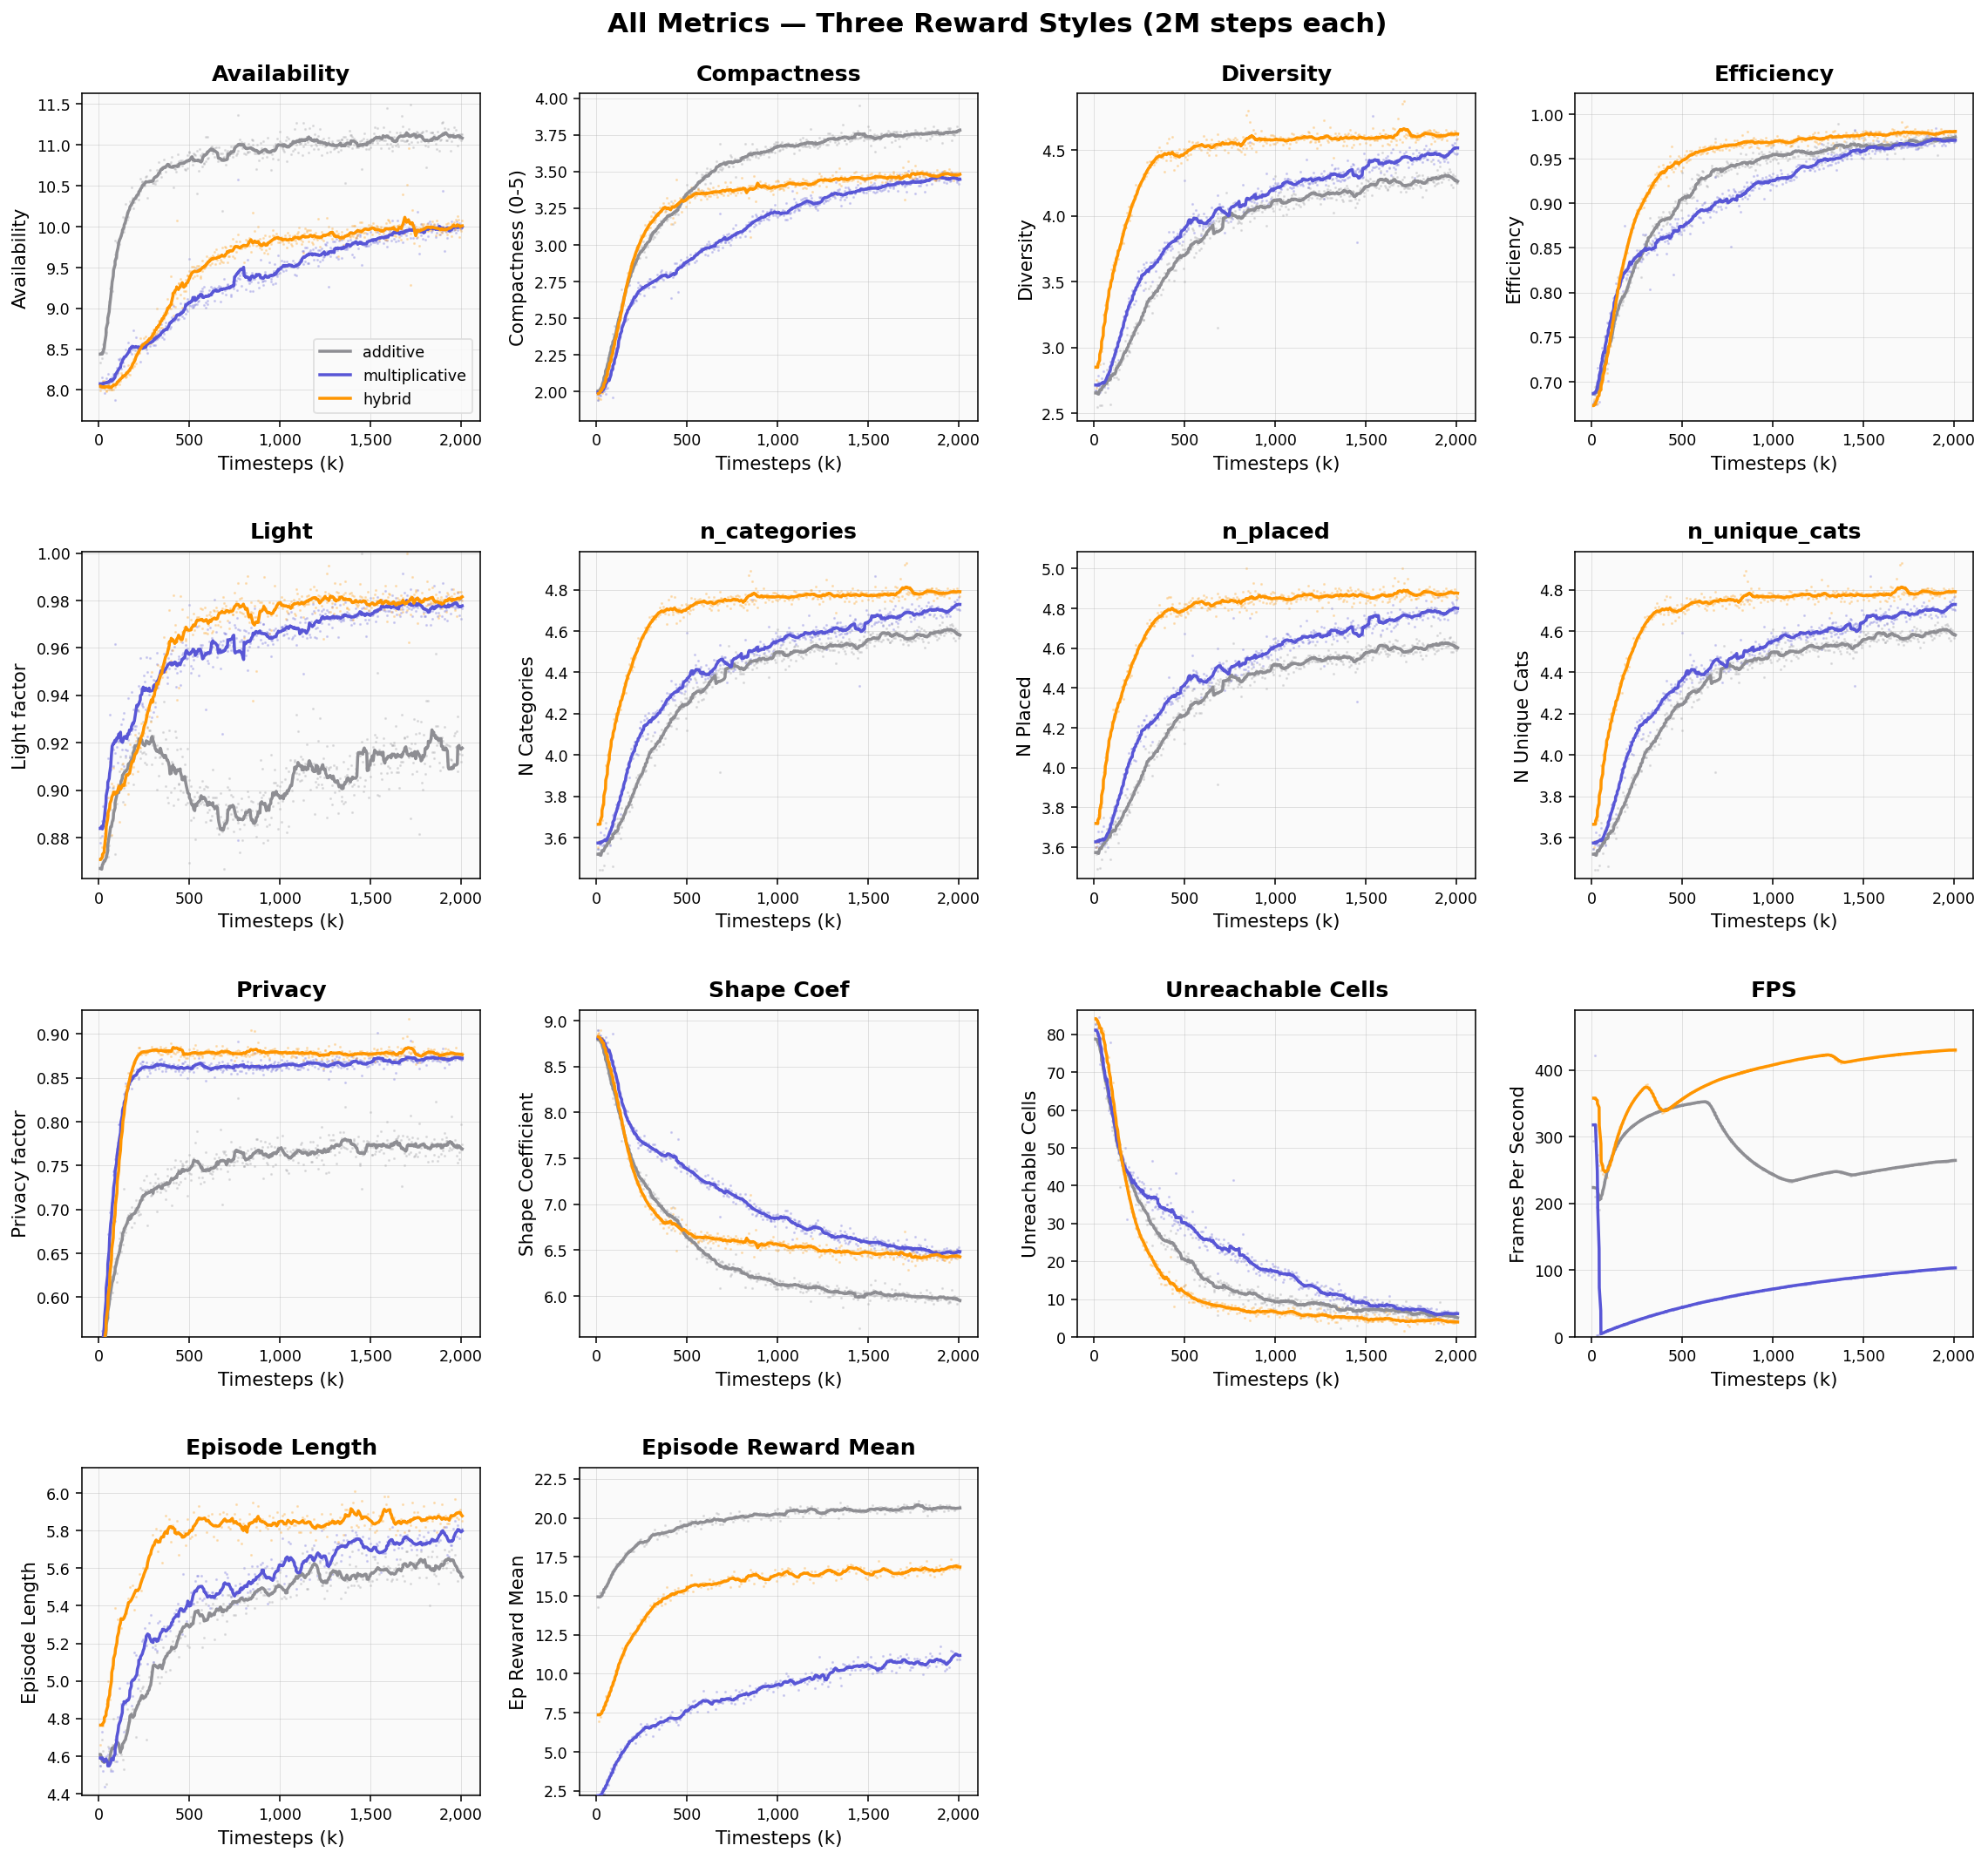

Saved -> plots/all_metrics.png


In [3]:
METRICS = [
    ("custom/availability",    "Availability",           "Availability"),
    ("custom/compactness",     "Compactness",            "Compactness (0-5)"),
    ("custom/diversity",       "Diversity",              "Diversity"),
    ("custom/efficiency",      "Efficiency",             "Efficiency"),
    ("custom/light",           "Light",                  "Light factor"),
    ("custom/n_categories",    "n_categories",           "N Categories"),
    ("custom/n_placed",        "n_placed",               "N Placed"),
    ("custom/n_unique_cats",   "n_unique_cats",          "N Unique Cats"),
    ("custom/privacy",         "Privacy",                "Privacy factor"),
    ("custom/shape_coef",      "Shape Coef",             "Shape Coefficient"),
    ("custom/unreachable",     "Unreachable Cells",      "Unreachable Cells"),
    ("time/fps",               "FPS",                    "Frames Per Second"),
    ("rollout/ep_len_mean",    "Episode Length",         "Episode Length"),
    ("rollout/ep_rew_mean",    "Episode Reward Mean",    "Ep Reward Mean"),
]

N = len(METRICS)
ncols = 4
nrows = (N + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.2 * nrows))
fig.subplots_adjust(wspace=0.25, hspace=0.40, top=0.94)
fig.suptitle("All Metrics — Three Reward Styles (2M steps each)",
             fontsize=16, weight="bold", y=0.98)

for idx, (col, title, ylabel) in enumerate(METRICS):
    row, col_idx = divmod(idx, ncols)
    ax = axes[row][col_idx] if nrows > 1 else axes[col_idx]
    # Find reasonable ylim from data
    all_vals = []
    for style in ["hybrid", "additive", "multiplicative"]:
        df = dfs[style]
        if col in df.columns:
            all_vals.append(df[col].dropna().values)
    if all_vals:
        concat = np.concatenate(all_vals)
        lo, hi = np.percentile(concat, [2, 98])
        margin = (hi - lo) * 0.15
        ylim = (max(0, lo - margin), hi + margin)
    else:
        ylim = None
    
    plot_metric(ax, col, title, ylabel, ylim=ylim, legend=(idx == 0))

# Hide unused subplots
for idx in range(N, nrows * ncols):
    row, col_idx = divmod(idx, ncols)
    axes[row][col_idx].set_visible(False)

plt.savefig("plots/all_metrics.png", dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved -> plots/all_metrics.png")

## Summary — Final Rollout Metrics (mean +- std of last 20 rows)


In [4]:
METRICS = [
    "eval/mean_reward",
    "custom/availability",
    "custom/diversity",
    "custom/compactness",
    "custom/privacy",
    "custom/light",
    "custom/efficiency",
    "custom/n_placed",
    "custom/n_categories",
    "custom/unreachable",
]
N = 20

rows = []
for style in ["hybrid", "additive", "multiplicative"]:
    df = dfs[style]
    tail = df.tail(N)
    row = {"style": LABELS[style]}
    for m in METRICS:
        if m in df.columns:
            row[m.split("/")[-1]] = f"{tail[m].mean():.3f} ± {tail[m].std():.3f}"
    rows.append(row)

summary = pd.DataFrame(rows).set_index("style")
summary.columns = [c.replace("custom/", "") for c in METRICS]
summary.columns = [c.replace("eval/", "eval_") for c in summary.columns]
summary

,eval_mean_reward,availability,diversity,compactness,privacy,light,efficiency,n_placed,n_categories,unreachable
style,,,,,,,,,,
hybrid,17.045 ± 0.628,9.998 ± 0.070,4.616 ± 0.022,3.482 ± 0.018,0.878 ± 0.003,0.981 ± 0.003,0.980 ± 0.002,4.874 ± 0.016,4.786 ± 0.012,4.086 ± 0.313
additive,20.980 ± 0.477,11.104 ± 0.068,4.290 ± 0.037,3.771 ± 0.020,0.773 ± 0.012,0.913 ± 0.021,0.973 ± 0.002,4.617 ± 0.022,4.597 ± 0.022,5.459 ± 0.560
multiplicative,11.747 ± 0.847,9.981 ± 0.048,4.482 ± 0.045,3.449 ± 0.020,0.872 ± 0.003,0.978 ± 0.003,0.970 ± 0.002,4.787 ± 0.025,4.709 ± 0.025,6.238 ± 0.410


## 2. Radar Chart — Multi-Dimensional Agent Profile

Six behavioural metrics, each normalised to [0, 1] (higher = better), computed from 200 deterministic eval episodes per agent at convergence (best checkpoint).

**Upper half — soft preferences (greed):** Coverage, Diversity, Compactness.  
**Lower half — hard constraints (dignity):** Privacy, Lighting, Reachability.

Origin zoomed to 0.55 to amplify differences in the operating range.

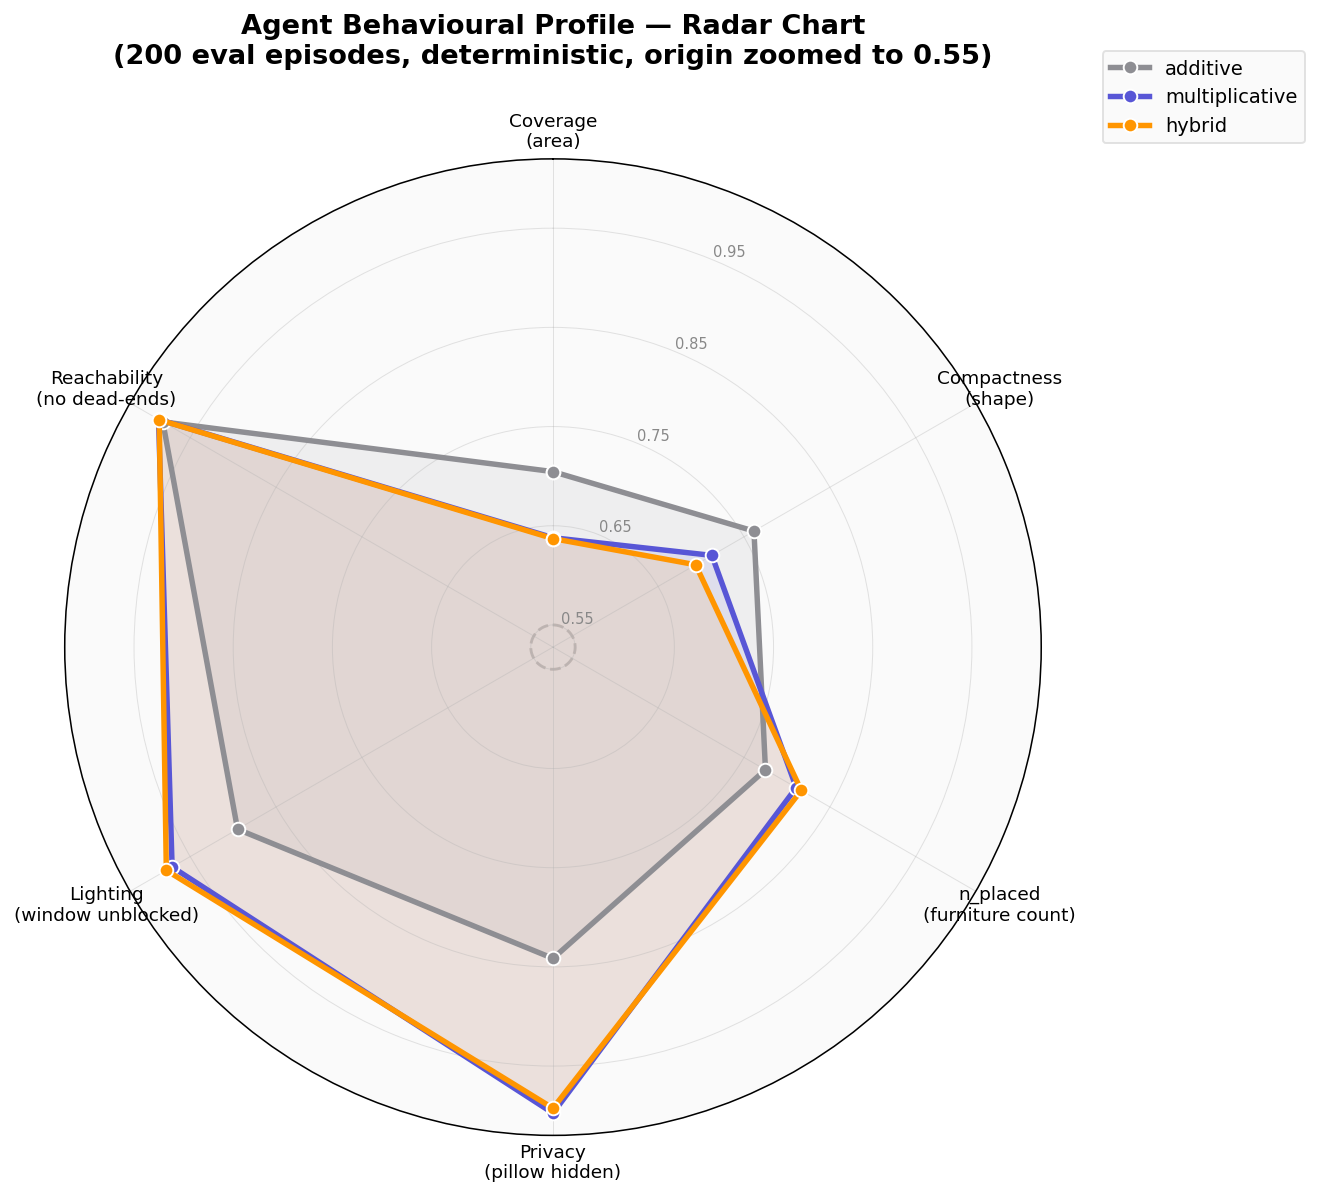

Saved -> plots/radar_profile.png

Raw scores (higher = better):
         Metric    hybrid  additive      mult
       coverage    0.6371    0.7046    0.6379
    compactness    0.6937    0.7616    0.7126
       n_placed    0.8167    0.7750    0.8108
        privacy    0.9925    0.8415    0.9975
       lighting    0.9778    0.8948    0.9710
   reachability    0.9860    0.9818    0.9868


In [5]:
import json

with open("plots/radar_metrics.json") as f:
    raw = json.load(f)

AGENTS = ["hybrid", "additive", "multiplicative"]

METRIC_KEYS = [
    "coverage",     "compactness",  "n_placed",      # upper half — soft / greed
    "privacy",      "lighting",     "reachability",  # lower half — hard / dignity
]
METRIC_NAMES = [
    "Coverage\n(area)",
    "Compactness\n(shape)",
    "n_placed\n(furniture count)",
    "Privacy\n(pillow hidden)",
    "Lighting\n(window unblocked)",
    "Reachability\n(no dead-ends)",
]

N = len(METRIC_KEYS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ZOOM = 0.55

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
fig.subplots_adjust(top=0.88, bottom=0.05)

ax.set_rmin(ZOOM)
ax.set_rmax(1.02)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for agent in ["additive", "multiplicative", "hybrid"]:
    vals = [raw[agent][k] for k in METRIC_KEYS] + [raw[agent][METRIC_KEYS[0]]]
    ax.fill(angles, vals, alpha=0.10, color=COLORS[agent])
    ax.plot(angles, vals, color=COLORS[agent], lw=2.8, label=agent,
            marker="o", ms=7, markeredgecolor="white", markeredgewidth=1.0, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_NAMES, fontsize=9.5)
ax.set_yticks([0.55, 0.65, 0.75, 0.85, 0.95])
ax.set_yticklabels(["0.55", "0.65", "0.75", "0.85", "0.95"], fontsize=7.5, color="#888")

theta_ring = np.linspace(0, 2 * np.pi, 200)
ax.plot(theta_ring, np.full(200, ZOOM), color="#ccc", lw=1.5, ls="--", zorder=0)

ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12),
          frameon=True, fancybox=True, framealpha=0.85, edgecolor="#ddd", fontsize=10)
ax.set_title("Agent Behavioural Profile — Radar Chart\n"
             "(200 eval episodes, deterministic, origin zoomed to 0.55)",
             weight="bold", pad=25, fontsize=14)

fig.savefig("plots/radar_profile.png", dpi=200, facecolor="white",
            edgecolor="none", pad_inches=0.3)
plt.show()
plt.close(fig)
print("Saved -> plots/radar_profile.png")

print("\nRaw scores (higher = better):")
print(f"{'Metric':>15}  {'hybrid':>8}  {'additive':>8}  {'mult':>8}")
for key in METRIC_KEYS:
    vals = [raw[a][key] for a in AGENTS]
    print(f"{key:>15}  {vals[0]:>8.4f}  {vals[1]:>8.4f}  {vals[2]:>8.4f}")

## 3. Wall-Clock Training Efficiency

Eval mean reward as a function of real wall-clock time. Reveals which reward style achieves the highest performance per minute of training.

        hybrid: 78 min total
      additive: 126 min total
multiplicative: 320 min total


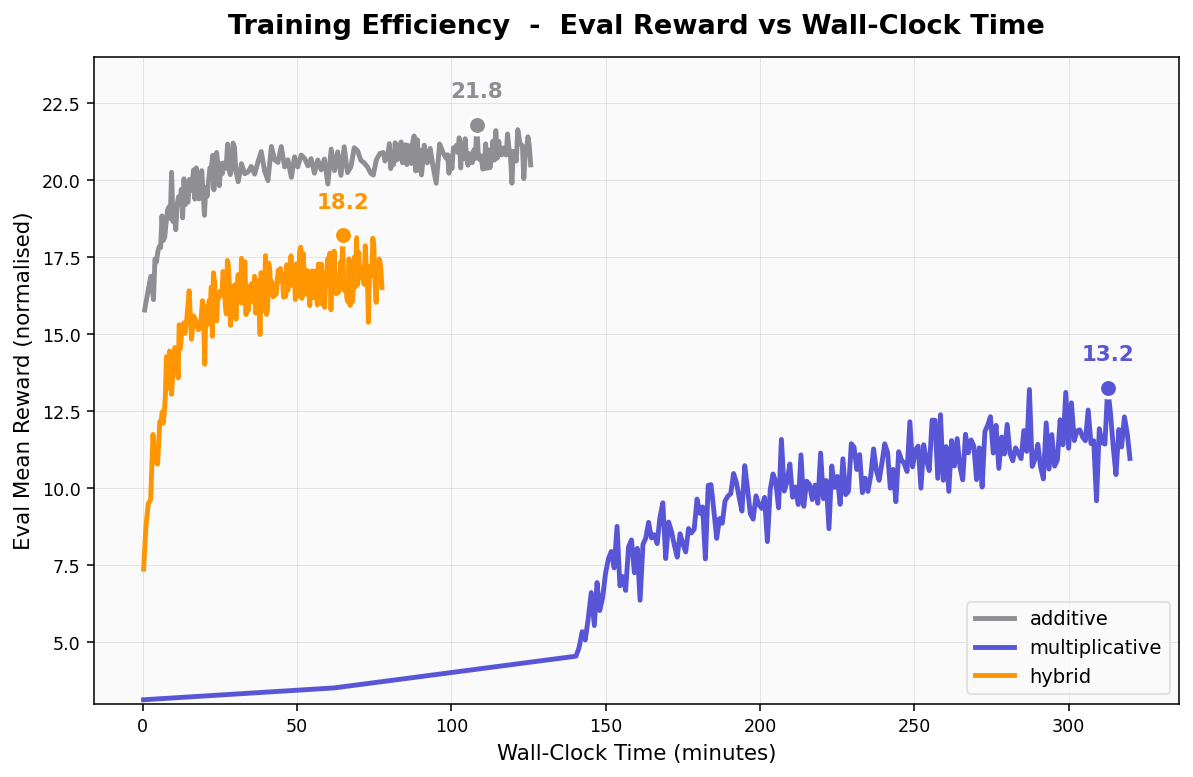

Saved -> plots/wall_clock_efficiency.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6.0))

EVAL_RUNS = {
    "hybrid":         "runs/ppo_2M_v2/evaluations.npz",
    "additive":       "runs/pilot_additive_2M/evaluations.npz",
    "multiplicative": "runs/pilot_mult/evaluations.npz",
}

for style in ["additive", "multiplicative", "hybrid"]:
    eval_path = EVAL_RUNS[style]
    data = np.load(eval_path)
    eval_ts = data["timesteps"]
    means = data["results"].mean(axis=1)
    df = dfs[style]
    mask = df["time/time_elapsed"].notna()
    ts_p = df.loc[mask, "time/total_timesteps"].values
    time_el = df.loc[mask, "time/time_elapsed"].values
    eval_min = np.interp(eval_ts, ts_p, time_el) / 60.0
    ax.plot(eval_min, means, color=COLORS[style], lw=2.5, label=style, zorder=3)
    best_i = np.argmax(means)
    ax.scatter(eval_min[best_i], means[best_i], color=COLORS[style],
               s=90, zorder=5, edgecolors="white", lw=1.8)
    ax.annotate(f"{means[best_i]:.1f}",
                (eval_min[best_i], means[best_i]),
                textcoords="offset points", xytext=(0, 14),
                fontsize=11, color=COLORS[style], weight="bold", ha="center")

ax.set_title("Training Efficiency  -  Eval Reward vs Wall-Clock Time", weight="bold", pad=12, fontsize=14)
ax.set_xlabel("Wall-Clock Time (minutes)", fontsize=11)
ax.set_ylabel("Eval Mean Reward (normalised)", fontsize=11)
ax.legend(frameon=True, fancybox=True, framealpha=0.85, edgecolor="#ddd", fontsize=10, loc="lower right")
ax.set_ylim(3, 24)
ax.grid(True, alpha=0.3)

for style in ["hybrid", "additive", "multiplicative"]:
    mask = dfs[style]["time/time_elapsed"].notna()
    total_min = dfs[style].loc[mask, "time/time_elapsed"].max() / 60
    print(f"{style:>14}: {total_min:.0f} min total")

plt.savefig("plots/wall_clock_efficiency.png", dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved -> plots/wall_clock_efficiency.png")


## 4. Eval Reward Progression (evaluations.npz)

Deterministic evaluation curve — cleaner signal than rollout reward.

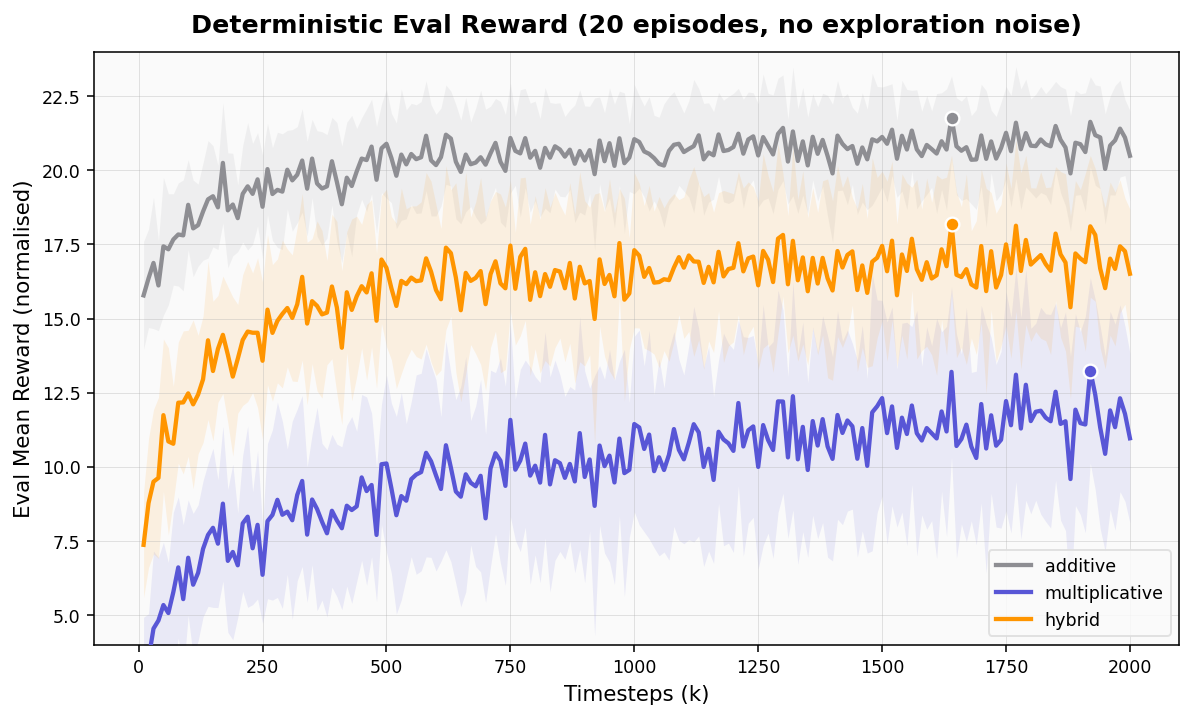

Saved → plots/eval_progression.png
      additive: peak eval = 18.21 @ step 1,640,000
multiplicative: peak eval = 18.21 @ step 1,640,000
        hybrid: peak eval = 18.21 @ step 1,640,000


In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

EVAL_RUNS = {
    "hybrid":         "runs/ppo_2M_v2/evaluations.npz",
    "additive":       "runs/pilot_additive_2M/evaluations.npz",
    "multiplicative": "runs/pilot_mult/evaluations.npz",
}

for style in ["additive", "multiplicative", "hybrid"]:
    path = EVAL_RUNS[style]
    data = np.load(path)
    ts = data["timesteps"] / 1000
    results = data["results"]  # (n_evals, n_episodes)
    means = results.mean(axis=1)
    stds = results.std(axis=1)
    ax.plot(ts, means, color=COLORS[style], lw=2.2, label=LABELS[style], zorder=3)
    ax.fill_between(ts, means - stds, means + stds,
                    color=COLORS[style], alpha=0.10, lw=0, zorder=1)
    # Mark best point
    best_idx = np.argmax(means)
    ax.scatter(ts[best_idx], means[best_idx], color=COLORS[style],
               s=50, zorder=5, edgecolors="white", lw=1.2)

ax.set_title("Deterministic Eval Reward (20 episodes, no exploration noise)",
             weight="bold", pad=10)
ax.set_xlabel("Timesteps (k)")
ax.set_ylabel("Eval Mean Reward (normalised)")
ax.legend(frameon=True, fancybox=True, framealpha=0.85, edgecolor="#ddd")
ax.set_ylim(4, 24)
ax.grid(True, alpha=0.35, lw=0.5)

plt.savefig("plots/eval_progression.png", dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved → plots/eval_progression.png")

# Print peak values
for style in ["additive", "multiplicative", "hybrid"]:
    data = np.load(path)
    means = data["results"].mean(axis=1)
    best_idx = np.argmax(means)
    print(f"{style:>14}: peak eval = {means[best_idx]:.2f} @ step {data['timesteps'][best_idx]:,.0f}")

## 5. Spatial Distribution & Room-Size Robustness (hybrid agent)

Bed and wardrobe centre positions across 1000 random rooms (288–572 cells), normalised to room coordinates (0–1).  Scatter of geometric discount score (privacy × light × efficiency) vs room area.

Small rooms (<350 cells): mean geo = 0.731 ± 0.177  (n=171)
Large rooms (>=450 cells): mean geo = 0.909 ± 0.067  (n=373)
Overall mean geo = 0.854 ± 0.127


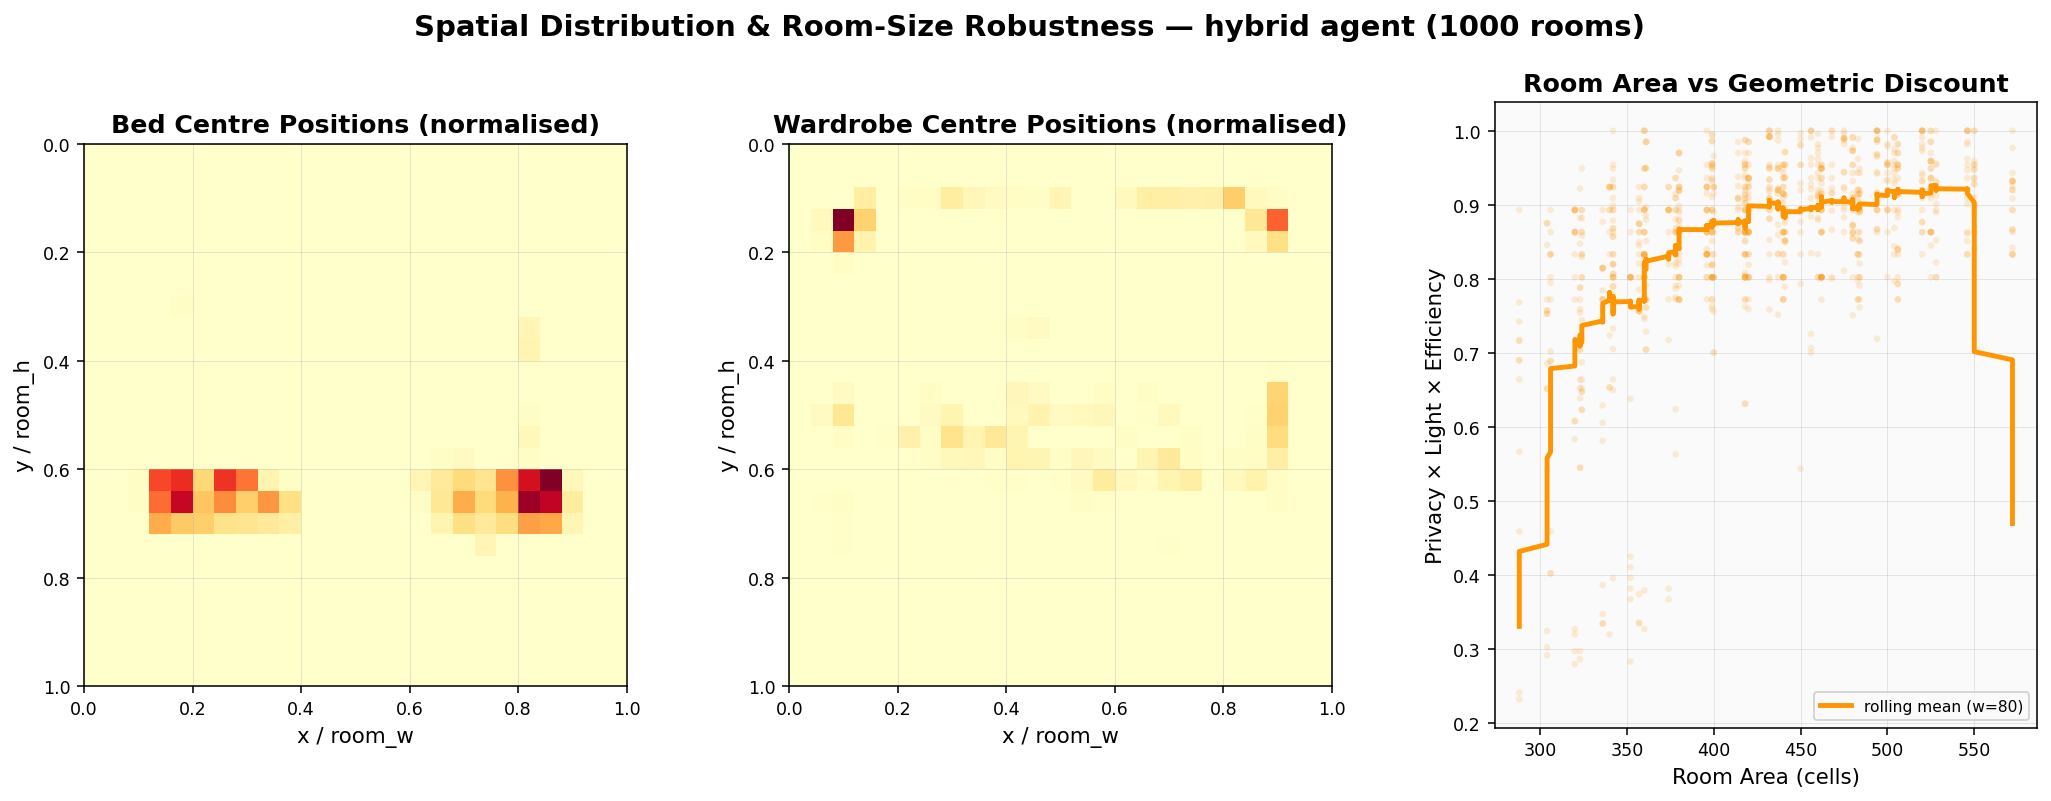

Saved -> plots/spatial_robustness.png


In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("plots/behavior_data.json") as f:
    data = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
fig.subplots_adjust(wspace=0.30, top=0.88)
fig.suptitle("Spatial Distribution & Room-Size Robustness — hybrid agent (1000 rooms)",
             fontsize=15, weight="bold", y=0.99)

# 1. Bed centre heatmap (normalised coords)
ax = axes[0]
bed_xy = [(x/rw, y/rh) for x, y, rw, rh in data["bed_positions"]]
bx, by = zip(*bed_xy)
ax.hist2d(bx, by, bins=25, cmap="YlOrRd", range=[[0, 1], [0, 1]])
ax.set_title("Bed Centre Positions (normalised)", weight="bold")
ax.set_xlabel("x / room_w"); ax.set_ylabel("y / room_h")
ax.set_xlim(0, 1); ax.set_ylim(1, 0)
ax.set_aspect("equal")

# 2. Wardrobe centre heatmap (normalised coords)
ax = axes[1]
ward_xy = [(x/rw, y/rh) for x, y, rw, rh in data["wardrobe_positions"]]
wx, wy = zip(*ward_xy)
ax.hist2d(wx, wy, bins=25, cmap="YlOrRd", range=[[0, 1], [0, 1]])
ax.set_title("Wardrobe Centre Positions (normalised)", weight="bold")
ax.set_xlabel("x / room_w"); ax.set_ylabel("y / room_h")
ax.set_xlim(0, 1); ax.set_ylim(1, 0)
ax.set_aspect("equal")

# 3. Room area vs geometric discount
ax = axes[2]
areas = [s[0]*s[1] for s in data["room_sizes"]]
scores = [g[1] for g in data["geo_scores"]]
ax.scatter(areas, scores, c="#FF9500", alpha=0.15, s=12, edgecolors="none")

# Trend line (rolling mean)
order = np.argsort(areas)
a_sorted = np.array(areas)[order]
s_sorted = np.array(scores)[order]
window = 80
trend = np.convolve(s_sorted, np.ones(window)/window, mode="same")
ax.plot(a_sorted, trend, color="#FF9500", lw=2.5, label="rolling mean (w=80)")

ax.set_title("Room Area vs Geometric Discount", weight="bold")
ax.set_xlabel("Room Area (cells)")
ax.set_ylabel("Privacy × Light × Efficiency")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

small = np.array(scores)[np.array(areas) < 350]
large = np.array(scores)[np.array(areas) >= 450]
print(f"Small rooms (<350 cells): mean geo = {small.mean():.3f} ± {small.std():.3f}  (n={len(small)})")
print(f"Large rooms (>=450 cells): mean geo = {large.mean():.3f} ± {large.std():.3f}  (n={len(large)})")
print(f"Overall mean geo = {np.mean(scores):.3f} ± {np.std(scores):.3f}")

plt.savefig("plots/spatial_robustness.png", dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved -> plots/spatial_robustness.png")

## 6. Intra-Episode Sequential Logic (hybrid agent)

Stacked bar chart of furniture category placed at each step (1–8) across 1000 episodes.  Reveals whether the agent learned human-like "big-first, small-later" common sense.

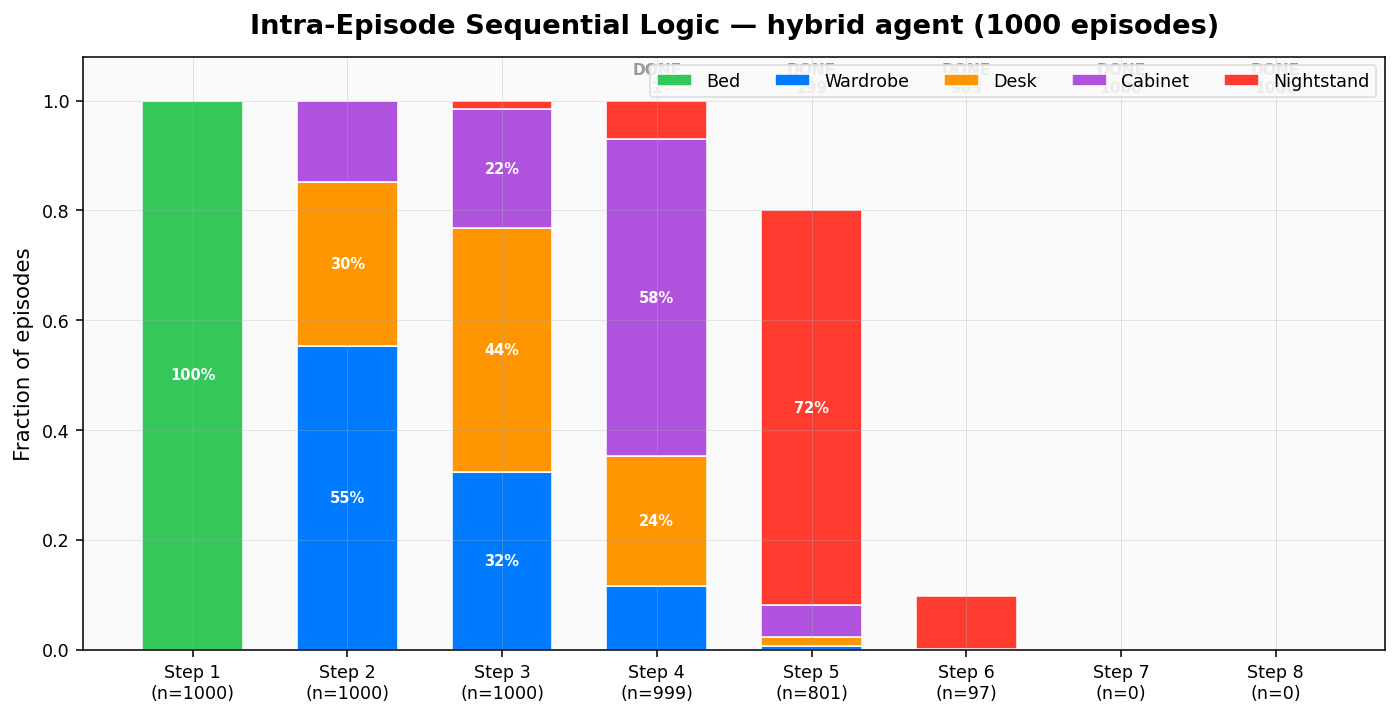

Saved -> plots/sequential_logic.png

Step summary:
  Step 1: bed=100%
  Step 2: wardrobe=55% | desk=30% | cabinet=15%
  Step 3: wardrobe=32% | desk=44% | cabinet=22% | nightstand=2%
  Step 4: wardrobe=12% | desk=24% | cabinet=58% | nightstand=7%
  Step 5: desk=2% | cabinet=6% | nightstand=72%
  Step 6: nightstand=10%
  Step 7: 
  Step 8: 


In [9]:
import json
from collections import Counter

with open("plots/behavior_data.json") as f:
    data = json.load(f)

step_cats = {int(k): v for k, v in data["step_categories"].items()}
all_cats = ["bed", "wardrobe", "desk", "cabinet", "nightstand"]
cat_colors = {
    "bed":        "#34C759",  # fresh green
    "wardrobe":   "#007AFF",  # calm blue
    "desk":       "#FF9500",  # warm amber (matches hybrid)
    "cabinet":    "#AF52DE",  # purple
    "nightstand": "#FF3B30",  # accent red
}

# Build stacked data
steps = sorted(step_cats.keys())
stack = {cat: [] for cat in all_cats}
totals = []
for s in steps:
    counts = Counter(step_cats[s])
    total = sum(counts.values())
    totals.append(total)
    for cat in all_cats:
        stack[cat].append(counts.get(cat, 0) / 1000)

fig, ax = plt.subplots(figsize=(12, 5.5))

bottom = np.zeros(len(steps))
x = np.arange(len(steps))
for cat in all_cats:
    vals = stack[cat]
    bars = ax.bar(x, vals, bottom=bottom, color=cat_colors[cat],
                  label=cat.capitalize(), width=0.65, edgecolor="white", lw=0.8)
    for i, v in enumerate(vals):
        if v > 0.15:
            ax.text(i, bottom[i] + v/2, f"{v:.0%}", ha="center", va="center",
                    fontsize=7.5, color="white", weight="bold")
    bottom += vals

# DONE marker
for i, s in enumerate(steps):
    if totals[i] < 1000:
        ax.text(i, 1.01, f"DONE\n{1000-totals[i]}", ha="center", va="bottom",
                fontsize=8, color="#999", weight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"Step {s}\n(n={totals[i]})" for i, s in enumerate(steps)])
ax.set_ylabel("Fraction of episodes")
ax.set_ylim(0, 1.08)
ax.legend(loc="upper right", frameon=True, fancybox=True, framealpha=0.85,
          edgecolor="#ddd", ncol=5, fontsize=9)
ax.set_title("Intra-Episode Sequential Logic — hybrid agent (1000 episodes)",
             weight="bold", pad=12, fontsize=14)
ax.grid(axis="y", alpha=0.3)

plt.savefig("plots/sequential_logic.png", dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved -> plots/sequential_logic.png")
print("\nStep summary:")
for i, s in enumerate(steps):
    cat_str = " | ".join(f"{cat}={stack[cat][i]:.0%}" for cat in all_cats if stack[cat][i] > 0.01)
    print(f"  Step {s}: {cat_str}")

## 7. Enhanced Learning Curve — hybrid agent (ppo_2M_v2)

Train rollout vs deterministic eval (±1σ band from `evaluations.npz`), with the
random-policy baseline and the best/final checkpoints marked. Side panel shows
training health: explained variance → 1 (value fit) and policy entropy ↓ (exploration → exploitation).

In [ ]:
import json
import matplotlib.ticker as mticker

RUN_HY = "ppo_2M_v2"
df = dfs["hybrid"]

def _sv(x, y, window=12):
    """Drop NaN, rolling-mean; return (x_valid, y_smoothed) with no line breaks."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = ~np.isnan(y); xv, yv = x[m], y[m]
    if len(yv) >= 3:
        yv = pd.Series(yv).rolling(window, center=True, min_periods=1).mean().values
    return xv, yv

evd = np.load(f"runs/{RUN_HY}/evaluations.npz")
ev_k, ev_m, ev_s = evd["timesteps"]/1000, evd["results"].mean(1), evd["results"].std(1)

try:
    with open("plots/evolution_data.json") as f:
        RAND = json.load(f)["random_baseline"]
except Exception:
    RAND = 6.9

C_TRAIN, C_EVAL, C_RAND, C_OK, C_ENT = "#FF9500", "#1C6DD0", "#FF3B30", "#34C759", "#AF52DE"

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5.6),
                              gridspec_kw={"width_ratios": [2.5, 1]})

ax.fill_between(ev_k, ev_m-ev_s, ev_m+ev_s, color=C_EVAL, alpha=0.15, zorder=2)
ax.plot(ev_k, ev_m, color=C_EVAL, lw=2.4, label="eval  (deterministic, ±1\u03c3)", zorder=4)
tx, ty = _sv(df["k_steps"], df["rollout/ep_rew_mean"], 12)
ax.plot(tx, ty, color=C_TRAIN, lw=2.2, label="train  (rollout mean)", zorder=5)
ax.axhline(RAND, color=C_RAND, lw=1.6, ls="--", alpha=0.85, zorder=2)
ax.text(ev_k.max(), RAND+0.4, f"random policy  ({RAND:.1f})", color=C_RAND,
        ha="right", va="bottom", fontsize=11, weight="bold")
bi = int(np.argmax(ev_m))
ax.scatter([ev_k[bi]], [ev_m[bi]], s=110, color=C_EVAL, zorder=6, edgecolors="white", lw=1.8)
ax.annotate(f"best {ev_m[bi]:.1f}", (ev_k[bi], ev_m[bi]), textcoords="offset points",
            xytext=(8, 10), fontsize=11, weight="bold", color=C_EVAL)
ax.annotate(f"final {ev_m[-1]:.1f}  ({ev_m[-1]/RAND:.1f}\u00d7 random)", (ev_k[-1], ev_m[-1]),
            textcoords="offset points", xytext=(-8, -22), ha="right", fontsize=11, color=C_EVAL)
ax.set_title("Learning Curve \u2014 hybrid agent (2 M steps)", weight="bold", fontsize=16, pad=10)
ax.set_xlabel("Timesteps (k)"); ax.set_ylabel("Episode reward"); ax.set_ylim(0, None)
ax.legend(loc="lower right", framealpha=0.92, edgecolor="#ddd", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

vx, vy = _sv(df["k_steps"], np.clip(df["train/explained_variance"], 0, 1), 8)
ex, ey = _sv(df["k_steps"], -df["train/entropy_loss"], 8)
ax2.plot(vx, vy, color=C_OK, lw=2.4)
ax2.set_ylabel("explained variance", color=C_OK); ax2.tick_params(axis="y", labelcolor=C_OK)
ax2.set_ylim(0, 1.02); ax2.set_xlabel("Timesteps (k)")
ax2.set_title("Training Health", weight="bold", fontsize=14, pad=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axb = ax2.twinx()
axb.plot(ex, ey, color=C_ENT, lw=2.4); axb.grid(False)
axb.set_ylabel("policy entropy", color=C_ENT); axb.tick_params(axis="y", labelcolor=C_ENT)
ax2.plot([], [], color=C_OK, lw=2.4, label="explained var \u2192 1")
ax2.plot([], [], color=C_ENT, lw=2.4, label="entropy \u2193")
ax2.legend(loc="center right", framealpha=0.92, edgecolor="#ddd", fontsize=10)

fig.tight_layout()
fig.savefig("plots/training_curve_hybrid.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"final eval {ev_m[-1]:.2f} | best {ev_m[bi]:.2f} | random {RAND:.2f}")

## 8. Behaviour Data — collect once, then cached

Heavy step: rolls out all 40 checkpoints of the hybrid agent and accumulates
spatial behaviour + occupancy maps. **Skips automatically if the cache files
exist.** Delete `plots/evolution_data.json` / `plots/occupancy_data.npz` to refresh.

In [ ]:
import os, subprocess, sys

if not os.path.exists("plots/evolution_data.json"):
    print("collecting evolution data (~4 min) ...")
    subprocess.run([sys.executable, "collect_evolution.py", "--n-eps", "300"], check=True)
else:
    print("\u2713 plots/evolution_data.json exists")

if not os.path.exists("plots/occupancy_data.npz"):
    print("collecting occupancy data (~3 min) ...")
    subprocess.run([sys.executable, "collect_occupancy.py", "--n-eps", "800"], check=True)
else:
    print("\u2713 plots/occupancy_data.npz exists")

with open("plots/evolution_data.json") as f:
    EVO = json.load(f)
OCC = np.load("plots/occupancy_data.npz")
print(f"loaded EVO ({len(EVO['checkpoints'])} checkpoints) + OCC")

## 9. Space Usage — Occupancy & Kept-Clear (final agent)

Aggregated over all sampled rooms in normalised coordinates (door at the bottom).
Furniture concentrates on walls and corners; the agent consistently keeps the
centre and a circulation band clear — the visual counterpart of the
**efficiency** (reachable space) and **compactness** rewards.

In [ ]:
occ = OCC["occ_final"]; free = 1 - occ
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
fig.suptitle("Where the agent puts furniture \u2014 and what it keeps clear\n"
             f"normalised over {EVO['n_eps']}+ rooms \u00b7 door at bottom",
             fontsize=15, weight="bold", y=1.05)
for ax, (m, title, cmap) in zip(axes, [(occ, "Furniture occupancy", "YlOrRd"),
                                       (free, "Kept clear (circulation)", "Blues")]):
    im = ax.imshow(m, cmap=cmap, origin="upper", aspect="equal", vmin=0, vmax=1)
    ax.set_title(title, weight="bold", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig("plots/space_usage.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 10. Learned Spatial Grammar — per-category occupancy (final agent)

Full-footprint occupancy per category. **Darker = more often occupied**; each
panel is scaled to its own peak (printed in the title) because categories differ
in size and frequency. Bed against side walls, wardrobe in the top corner, desk
along top/left walls, cabinet on the top wall, nightstand a tight spot by the bed.


In [ ]:
cats = ["bed", "wardrobe", "desk", "cabinet", "nightstand"]
cmaps = {"bed":"Greens","wardrobe":"Blues","desk":"Oranges","cabinet":"Purples","nightstand":"Reds"}
fig, axes = plt.subplots(1, 5, figsize=(16, 4.2))
fig.suptitle("Learned spatial grammar \u2014 darker = more often occupied "
             "(each panel scaled to its own peak; door at bottom)",
             fontsize=14, weight="bold", y=1.04)
for ax, c in zip(axes, cats):
    m = OCC[f"occ_{c}"]
    vmax = max(0.08, float(m.max()))
    im = ax.imshow(m, cmap=cmaps[c], origin="upper", aspect="equal", vmin=0, vmax=vmax)
    ax.set_title(f"{c.capitalize()}   (peak {m.max():.0%})", weight="bold", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.06, orientation="horizontal")
    cb.set_ticks([0, vmax]); cb.set_ticklabels(["empty", "occupied"])
    cb.ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig("plots/spatial_grammar.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 11. Spatial Behaviour Evolution — bed & wardrobe across training

**Full-footprint** occupancy (every cell a piece covers, not just its centre) at
six checkpoints, so large furniture is shown at true size and edge-to-wall
alignment is visible. Early placements are diffuse; they consolidate into solid
wall/corner blocks as training proceeds.


In [ ]:
rows = [("bed", "Bed", "Greens"), ("wardrobe", "Wardrobe", "Blues")]
steps_o = OCC["checkpoints"]; n = len(steps_o)
fig, axes = plt.subplots(len(rows), n, figsize=(2.7*n, 2.7*len(rows)))
fig.suptitle("Spatial behaviour matures over training \u2014 full footprint (edges included), "
             "darker = more often occupied", fontsize=14, weight="bold", y=1.03)
for r, (cat, label, cmap) in enumerate(rows):
    maps = OCC[f"occ_evo_{cat}"]
    vmax = max(0.05, float(maps.max()))
    for c, (step, m) in enumerate(zip(steps_o, maps)):
        ax = axes[r][c]
        im = ax.imshow(m, cmap=cmap, origin="upper", aspect="equal", vmin=0, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(f"{step/1e6:.2f}M", fontsize=11, weight="bold")
        if c == 0:
            ax.set_ylabel(label, fontsize=12, weight="bold")
    cb = fig.colorbar(im, ax=list(axes[r]), fraction=0.012, pad=0.01)
    cb.set_ticks([0, vmax]); cb.set_ticklabels(["empty", "occupied"])
    cb.ax.tick_params(labelsize=8)
fig.savefig("plots/evolution_filmstrip.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 12. Circulation Space Emerges Over Training

Kept-clear maps (blue = consistently left empty) at six checkpoints. The central
circulation band and door clearance sharpen as the agent learns.

In [ ]:
steps_o = OCC["checkpoints"]; rates = OCC["occ_rate"]; n = len(steps_o)
fig, axes = plt.subplots(1, n, figsize=(2.6*n, 3.0))
fig.suptitle("Circulation space emerges over training \u2014 kept-clear map sharpens",
             fontsize=14, weight="bold", y=1.10)
for ax, step, rate in zip(axes, steps_o, rates):
    ax.imshow(1 - rate, cmap="Blues", origin="upper", aspect="equal", vmin=0, vmax=1)
    ax.set_title(f"{step/1e6:.2f}M", fontsize=12, weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig("plots/circulation_evolution.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 13. What the Agent Learns, and When — reward components over training

Mean ±1σ of each reward component across 300 deterministic episodes per
checkpoint. Availability and the soft factors (efficiency, privacy, light) rise
together; the soft factors are shown on their own [0,1] axis to stay legible.

In [ ]:
steps_e = EVO["checkpoints"]; ks = np.array(steps_e)/1e6
comp_colors = {"availability":"#FF9500","privacy":"#1C6DD0","light":"#34C759",
               "efficiency":"#FF3B30","diversity":"#AF52DE","compactness":"#00B8A9"}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.4))
for title, keys, ax in [("Base & bonuses", ["availability", "diversity", "compactness"], axL),
                        ("Soft factors (0\u20131)", ["privacy", "light", "efficiency"], axR)]:
    for key in keys:
        m = np.array([EVO["by_ckpt"][str(s)]["components"][key][0] for s in steps_e])
        sd = np.array([EVO["by_ckpt"][str(s)]["components"][key][1] for s in steps_e])
        ax.plot(ks, m, color=comp_colors[key], lw=2.4, label=key, marker="o", ms=3)
        ax.fill_between(ks, m-sd, m+sd, color=comp_colors[key], alpha=0.12)
    ax.set_title(title, weight="bold", fontsize=13)
    ax.set_xlabel("Timesteps (M)")
    ax.legend(framealpha=0.92, edgecolor="#ddd", fontsize=10)
axL.set_ylabel("value")
fig.suptitle("What the agent learns, and when \u2014 reward components over training",
             weight="bold", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig("plots/component_trajectories.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 14. Reward Composition vs Space Usage — 3-style comparison

The radar chart compares the three reward-composition agents on *quantitative*
behaviour metrics; this compares them *spatially*. Each agent's best model is
rolled out on the **same room sequence**, so any difference in the occupancy map
is attributable to the reward composition alone.

Collected once into `plots/occupancy_styles.npz` (skips if cached).

In [ ]:
import os, subprocess, sys
if not os.path.exists("plots/occupancy_styles.npz"):
    print("collecting 3-style occupancy (~5 min) ...")
    subprocess.run([sys.executable, "collect_occupancy_styles.py", "--n-eps", "600"], check=True)
else:
    print("\u2713 plots/occupancy_styles.npz exists")
STY = np.load("plots/occupancy_styles.npz")
print("styles:", list(STY["styles"]))

In [ ]:
styles = ["hybrid", "additive", "multiplicative"]
CATS = ["bed", "wardrobe", "desk", "cabinet", "nightstand"]
SC = {"hybrid": "#FF9500", "additive": "#8E8E93", "multiplicative": "#5856D6"}
titles = {"hybrid": "Hybrid", "additive": "Additive", "multiplicative": "Multiplicative"}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.2))
fig.suptitle("Reward composition shapes spatial behaviour\n"
             "top: furniture occupancy (normalised, door at bottom)   \u00b7   "
             "bottom-left: usage by category   \u00b7   bottom-mid/right: difference vs hybrid",
             fontsize=14, weight="bold", y=1.02)

hyb = STY["occ_hybrid"]
for j, st in enumerate(styles):
    ax = axes[0][j]
    im = ax.imshow(STY[f"occ_{st}"], cmap="YlOrRd", origin="upper", aspect="equal", vmin=0, vmax=1)
    ax.set_title(f"{titles[st]}   ({STY[f'occ_{st}'].mean():.0%} occupied)", weight="bold", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[0], fraction=0.025, pad=0.02, label="occupancy rate")

ax = axes[1][0]
x = np.arange(len(CATS)); w = 0.26
for k, st in enumerate(styles):
    vals = [STY[f"occ_{st}_{c}"].mean() for c in CATS]
    ax.bar(x + (k-1)*w, vals, w, color=SC[st], label=titles[st], edgecolor="white", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([c[:4] for c in CATS], fontsize=9)
ax.set_ylabel("mean occupancy"); ax.set_title("Usage by category", fontsize=11, weight="bold")
ax.legend(fontsize=8.5, framealpha=0.9)

for j, st in enumerate(["additive", "multiplicative"]):
    ax = axes[1][j+1]
    im2 = ax.imshow(STY[f"occ_{st}"] - hyb, cmap="RdBu_r", origin="upper",
                    aspect="equal", vmin=-0.4, vmax=0.4)
    ax.set_title(f"{st} \u2212 hybrid", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im2, ax=[axes[1][1], axes[1][2]], fraction=0.025, pad=0.02, label="\u0394 occupancy")

fig.savefig("plots/occupancy_styles.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print({st: round(float(STY[f"occ_{st}"].mean()), 3) for st in styles})

## 15. Reward Distribution by Composition Style

Distribution (not just the mean) of episode reward for the three agents on the
same 500 rooms, hybrid yardstick. The mean-only radar hides spread — additive
has a noticeably wider, lower distribution (less consistent), while hybrid and
multiplicative are tighter. Collected once into `plots/style_rewards.npz`.

In [ ]:
import os, subprocess, sys
if not os.path.exists("plots/style_rewards.npz"):
    print("collecting per-episode style rewards (~2 min) ...")
    subprocess.run([sys.executable, "collect_style_rewards.py", "--n-eps", "500"], check=True)
SR = np.load("plots/style_rewards.npz")
STYLES = ["hybrid", "additive", "multiplicative"]
SC = {"hybrid": "#FF9500", "additive": "#8E8E93", "multiplicative": "#5856D6"}

fig, ax = plt.subplots(figsize=(9, 5.4))
data = [SR[f"total_{s}"] for s in STYLES]
parts = ax.violinplot(data, showmeans=True, showextrema=False, widths=0.85)
for i, b in enumerate(parts["bodies"]):
    b.set_facecolor(SC[STYLES[i]]); b.set_alpha(0.55); b.set_edgecolor("white")
parts["cmeans"].set_color("#333")
for i, s in enumerate(STYLES):
    y = SR[f"total_{s}"]
    x = np.random.default_rng(i).normal(i + 1, 0.05, len(y))
    ax.scatter(x, y, s=5, color=SC[s], alpha=0.18, zorder=1)
    ax.text(i + 1.12, y.mean(), f"{y.mean():.1f}\u00b1{y.std():.1f}",
            fontsize=10, weight="bold", va="center")
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(STYLES, fontsize=11)
ax.set_ylabel("Episode reward (hybrid yardstick)")
ax.set_title("Reward distribution by composition style (500 eps, same rooms)",
             weight="bold", fontsize=14)
fig.tight_layout()
fig.savefig("plots/reward_distribution.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 16. Reward Component Correlations (hybrid)

Pearson correlation between the six components across 500 episodes. Reveals the
built-in trade-offs: **compactness anti-correlates with availability and
diversity** — more furniture and more variety leave messier empty space — while
availability, privacy and diversity move together.

In [ ]:
COMPS = ["availability", "privacy", "light", "efficiency", "diversity", "compactness"]
M = np.stack([SR[f"{c}_hybrid"] for c in COMPS])
corr = np.corrcoef(M)
fig, ax = plt.subplots(figsize=(6.8, 5.8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(6)); ax.set_xticklabels([c[:4] for c in COMPS], rotation=45, ha="right")
ax.set_yticks(range(6)); ax.set_yticklabels(COMPS)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr[i,j]) > 0.5 else "#333", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Reward component correlations (hybrid, 500 eps)", weight="bold", fontsize=13)
fig.tight_layout()
fig.savefig("plots/component_correlation.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 17. Reward vs Room Size — generalization scatter

Episode reward against room area, all three styles, with a rolling-mean trend.
Performance is broadly flat across the randomized room sizes — evidence the
agents generalize rather than memorize a single floor plan.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.4))
for s in STYLES:
    a = SR[f"room_area_{s}"]; r = SR[f"total_{s}"]
    ax.scatter(a, r, s=10, color=SC[s], alpha=0.18, edgecolors="none", label=s)
    o = np.argsort(a); aa, rr = a[o], r[o]
    w = 60
    if len(rr) > w:
        tr = np.convolve(rr, np.ones(w)/w, mode="valid")
        ax.plot(aa[w//2:w//2+len(tr)], tr, color=SC[s], lw=2.6, zorder=4)
ax.set_xlabel("Room area (cells)"); ax.set_ylabel("Episode reward")
ax.set_title("Reward vs room size \u2014 generalization across rooms",
             weight="bold", fontsize=14)
ax.legend(fontsize=10, framealpha=0.9)
fig.tight_layout()
fig.savefig("plots/reward_vs_area.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 18. Space Usage — Heatmap vs Contour (final hybrid agent)

The same occupancy field as §9, shown as a filled contour. Contour bands make
the high-occupancy wall zones and the central kept-clear region read more
cleanly than the raw pixel grid. Darker = more often occupied.

In [ ]:
occ = OCC["occ_final"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.9))
fig.suptitle("Space usage \u2014 heatmap vs contour (final hybrid agent, door at bottom)",
             weight="bold", fontsize=14, y=1.03)
im = a1.imshow(occ, cmap="YlOrRd", origin="upper", aspect="equal", vmin=0, vmax=1)
a1.set_title("Occupancy (heatmap)", weight="bold"); a1.set_xticks([]); a1.set_yticks([])
fig.colorbar(im, ax=a1, fraction=0.046, pad=0.04, label="occupancy rate")
cf = a2.contourf(occ, levels=8, cmap="YlOrRd", origin="upper")
a2.contour(occ, levels=8, colors="white", linewidths=0.6, origin="upper")
a2.set_aspect("equal"); a2.invert_yaxis(); a2.set_xticks([]); a2.set_yticks([])
a2.set_title("Occupancy (contour)", weight="bold")
fig.colorbar(cf, ax=a2, fraction=0.046, pad=0.04, label="occupancy rate")
fig.tight_layout()
fig.savefig("plots/occupancy_contour.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 19. Furniture Territory by Composition Style — colour-coded overlay

All five categories overlaid on one map per style: each cell is coloured by the
category that **most often** occupies it, with brightness = occupancy frequency.
Reads as a "territory map" of the learned spatial grammar. Bed (green) fills the
lower two-thirds everywhere; the top-wall territory is where the styles diverge —
additive devotes a large block to the wardrobe and drops the cabinet, while
hybrid / multiplicative keep more cabinet. Nightstand (red) sits beside the bed
in all three. Data: `plots/occupancy_styles.npz` (from §14).

In [ ]:
from matplotlib.patches import Patch

styles = ["hybrid", "additive", "multiplicative"]
titles = {"hybrid": "Hybrid", "additive": "Additive", "multiplicative": "Multiplicative"}
CATS = ["bed", "wardrobe", "desk", "cabinet", "nightstand"]
CC = {"bed": (0.20, 0.78, 0.35), "wardrobe": (0.0, 0.48, 1.0), "desk": (1.0, 0.58, 0.0),
      "cabinet": (0.69, 0.32, 0.87), "nightstand": (1.0, 0.23, 0.19)}

def territory(style, gamma=0.7):
    maps = np.stack([STY[f"occ_{style}_{c}"] for c in CATS])   # (5, H, W)
    total = maps.sum(0)
    dom = maps.argmax(0)
    H, W = total.shape
    img = np.ones((H, W, 3))
    a = np.clip(total, 0, 1) ** gamma                          # alpha = occupancy (contrast-boosted)
    for i, c in enumerate(CATS):
        mask = (dom == i) & (total > 0.02)
        col = np.array(CC[c])
        for ch in range(3):
            img[..., ch] = np.where(mask, (1 - a) + a * col[ch], img[..., ch])
    return img

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
fig.suptitle("Furniture territory by reward composition  "
             "(each cell = dominant category; brightness = occupancy; door at bottom)",
             fontsize=13, weight="bold", y=1.05)
for ax, st in zip(axes, styles):
    ax.imshow(territory(st), origin="upper", aspect="equal")
    ax.set_title(f"{titles[st]}   ({STY[f'occ_{st}'].mean():.0%} occupied)", weight="bold", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
legend = [Patch(facecolor=CC[c], label=c.capitalize()) for c in CATS]
fig.legend(handles=legend, loc="lower center", ncol=5, frameon=True, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.savefig("plots/furniture_territory.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 20. Controlled-Geometry Comparison — fixed door & window, vary size

§14/§19 used **random** door/window, which blurs the relative spatial structure.
Here we **pin the geometry** — door near the left of the bottom wall, window
centred on the top wall — and vary only the room size. After normalising, door
and window become fixed anchors, so the three styles' furniture territories are
directly comparable. Collected once into `plots/fixed_dw_occupancy.npz`.

In [ ]:
import os, subprocess, sys
from matplotlib.patches import Patch, Rectangle
if not os.path.exists("plots/fixed_dw_occupancy.npz"):
    print("collecting fixed-geometry occupancy (~6 min) ...")
    subprocess.run([sys.executable, "collect_fixed_dw.py", "--n-eps", "800"], check=True)
FIXD = np.load("plots/fixed_dw_occupancy.npz")
print("loaded:", [s for s in FIXD["styles"]])

In [ ]:
from matplotlib.patches import Patch, Rectangle
STYLES = ["hybrid", "additive", "multiplicative"]
TITLES = {"hybrid":"Hybrid","additive":"Additive","multiplicative":"Multiplicative"}
CATS = ["bed","wardrobe","desk","cabinet","nightstand"]
CC = {"bed":(0.20,0.78,0.35),"wardrobe":(0.0,0.48,1.0),"desk":(1.0,0.58,0.0),
      "cabinet":(0.69,0.32,0.87),"nightstand":(1.0,0.23,0.19)}
NB_X, NB_Y = 26, 22

def _territory(style, gamma=0.7):
    maps = np.stack([FIXD[f"occ_{style}_{c}"] for c in CATS])
    total = maps.sum(0); dom = maps.argmax(0)
    img = np.ones((NB_Y, NB_X, 3)); a = np.clip(total, 0, 1) ** gamma
    for i, c in enumerate(CATS):
        mask = (dom == i) & (total > 0.02); col = np.array(CC[c])
        for ch in range(3):
            img[..., ch] = np.where(mask, (1 - a) + a * col[ch], img[..., ch])
    return img

def _mark_dw(ax):
    ax.add_patch(Rectangle((0.5, NB_Y-1.4), 6*NB_X/21, 1.3, facecolor="#FFD400",
                 edgecolor="k", lw=0.8, alpha=0.9, zorder=5))
    ax.text(3.5, NB_Y-1.6, "door", fontsize=8, weight="bold", ha="center", va="bottom", color="#7a5c00")
    ax.add_patch(Rectangle((NB_X/2-3, 0.1), 6, 1.2, facecolor="#7FD4FF",
                 edgecolor="k", lw=0.8, alpha=0.9, zorder=5))
    ax.text(NB_X/2, 1.5, "window", fontsize=8, weight="bold", ha="center", va="top", color="#1a5a7a")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("Furniture territory under fixed door & window  "
             "(door = left of bottom wall, window = top centre; only room size varies)",
             fontsize=13, weight="bold", y=1.05)
for ax, st in zip(axes, STYLES):
    ax.imshow(_territory(st), origin="upper", aspect="equal", extent=[0, NB_X, NB_Y, 0])
    _mark_dw(ax)
    ax.set_title(f"{TITLES[st]}   ({FIXD[f'occ_{st}'].mean():.0%} occupied)", weight="bold", fontsize=12)
    ax.set_xlim(0, NB_X); ax.set_ylim(NB_Y, 0); ax.set_xticks([]); ax.set_yticks([])
fig.legend(handles=[Patch(facecolor=CC[c], label=c.capitalize()) for c in CATS],
           loc="lower center", ncol=5, frameon=True, fontsize=10, bbox_to_anchor=(0.5, -0.03))
fig.savefig("plots/fixed_territory.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 21. Empty-Space Morphology — fixed geometry

The same controlled rollouts, now showing the **kept-clear** field (1 − occupancy)
as filled contours. In all three styles the empty space forms a **corridor from
the door** that the agent keeps open; the differences are in how consolidated it
is — additive leaves the most compact single clear region (compactness 3.85),
hybrid/multiplicative leave it slightly more spread out.

In [ ]:
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle
SRc = np.load("plots/style_rewards.npz")   # for mean compactness annotation

def _mark_dw_outline(ax):
    ax.add_patch(Rectangle((0.5, NB_Y-1.4), 6*NB_X/21, 1.3, facecolor="none",
                 edgecolor="#C8A000", lw=2, zorder=5))
    ax.text(3.5, NB_Y-1.6, "door", fontsize=8, weight="bold", ha="center", va="bottom", color="#7a5c00")
    ax.add_patch(Rectangle((NB_X/2-3, 0.1), 6, 1.2, facecolor="none",
                 edgecolor="#1a8ac0", lw=2, zorder=5))
    ax.text(NB_X/2, 1.5, "window", fontsize=8, weight="bold", ha="center", va="top", color="#1a5a7a")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("Empty-space morphology under fixed door & window  "
             "(blue = kept clear; contours = iso-occupancy)",
             fontsize=13, weight="bold", y=1.05)
ext = [0, NB_X, NB_Y, 0]
for ax, st in zip(axes, STYLES):
    free = 1 - FIXD[f"occ_{st}"]
    fz = zoom(free, 4, order=1)
    cf = ax.contourf(fz, levels=np.linspace(0, 1, 9), cmap="Blues", extent=ext, origin="upper")
    ax.contour(fz, levels=np.linspace(0, 1, 9), colors="white", linewidths=0.5, extent=ext, origin="upper")
    _mark_dw_outline(ax)
    comp = SRc[f"compactness_{st}"].mean()
    ax.set_title(f"{TITLES[st]}\nfree {free.mean():.0%} \u00b7 compactness {comp:.2f}/5",
                 weight="bold", fontsize=12)
    ax.set_xlim(0, NB_X); ax.set_ylim(NB_Y, 0); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(cf, ax=axes, fraction=0.018, pad=0.02, label="kept-clear rate")
fig.savefig("plots/fixed_freespace.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 22. Experimentation Journey — every training run (raw reward)

All **17** training runs (the complete set). x-axis = real steps (log) so length
is honest; y-axis = **raw rollout reward** so height is honest too (no per-run
min–max — that earlier version forced every curve to 1.0, which was misleading).
Pilots are coloured by length (short → long); the three final 2M runs use the
style theme colours.

| Phase | Runs | Steps | Reward formula |
|---|---|---|---|
| **A · bring-up** | ppo_run1/2 | 500K | **additive**: `Availability − Discomfort − Waste` (run1 diverged) |
| **B · mechanics + reward** | 9 pilots (hcw_*) | 30–100K | multiplicative core (v2) → + diversity/compactness (v3) |
| **C · converge** | ppo_2026…, pilot_v4/v5 | 500K | hybrid (v5) |
| **D · final ablation** | hybrid / additive / multiplicative | 2M | all three styles |

**Two caveats on reading height:**
1. **Across phases, heights are NOT comparable** — the reward formula changed
   (v1 additive → v2 multiplicative → v3/v5 hybrid), so a phase-B reward of 5
   and a phase-D reward of 17 are different units.
2. **Within the 3 finals, raw reward ≠ quality.** Additive trains highest (≈20.7)
   only because its own reward is easiest to push toward the shared 26.3 ceiling.
   On the *common* yardstick (§15) hybrid is actually best (16.7 vs additive 15.8).
   Each style maximizes a different objective, so compare quality on §15, not here.

In [ ]:
import glob

def _smooth(y, w=9):
    if len(y) < 3: return np.asarray(y, float)
    return pd.Series(y).rolling(w, center=True, min_periods=1).mean().values

FINAL = {"ppo_2M_v2": ("#FF9500", "hybrid (2M)"),
         "pilot_additive_2M": ("#8E8E93", "additive (2M)"),
         "pilot_mult": ("#5856D6", "multiplicative (2M)")}

runs = {}
for d in sorted(glob.glob("runs/*/")):
    p = os.path.join(d, "progress.csv")
    if not os.path.exists(p): continue
    try: rdf = pd.read_csv(p)
    except Exception: continue
    if "rollout/ep_rew_mean" not in rdf.columns: continue
    sub = rdf[["time/total_timesteps", "rollout/ep_rew_mean"]].dropna()
    if len(sub) < 3: continue
    runs[os.path.basename(d.rstrip("/"))] = (sub["time/total_timesteps"].values,
                                             sub["rollout/ep_rew_mean"].values)

pilots = sorted([n for n in runs if n not in FINAL], key=lambda n: runs[n][0].max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.axhline(26.3, color="#bbb", ls=":", lw=1.5, zorder=1)
ax.text(3.2e4, 26.3, " v5 theoretical max (26.3)", color="#999", fontsize=9, va="bottom")
for i, n in enumerate(pilots):
    ts, r = runs[n]; y = _smooth(r); c = cmap(i / max(1, len(pilots) - 1))
    ax.plot(ts, y, color=c, lw=1.5, alpha=0.7, solid_capstyle="round", zorder=2)
    ax.scatter([ts.max()], [y[-1]], s=16, color=c, alpha=0.8, zorder=3)
for n, (col, lab) in FINAL.items():
    if n not in runs: continue
    ts, r = runs[n]; y = _smooth(r)
    ax.plot(ts, y, color=col, lw=3.2, alpha=0.95, solid_capstyle="round", zorder=5, label=lab)
    ax.scatter([ts.max()], [y[-1]], s=75, color=col, edgecolors="white", lw=1.5, zorder=6)

ax.set_xscale("log"); ax.set_ylim(-1, 28)
ax.set_xlabel("Training steps (log)"); ax.set_ylabel("Raw episode reward (rollout mean)")
ax.set_title("Experimentation journey \u2014 17 runs, raw reward (real heights & lengths)\n"
             "pilots coloured by length \u00b7 finals in style colours \u00b7 "
             "heights across phases NOT comparable (reward formula changed)",
             weight="bold", fontsize=12.5, pad=10)
ax.legend(loc="upper left", fontsize=10, framealpha=0.93)
sm = plt.cm.ScalarMappable(cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("pilot length (short \u2192 long)"); cb.set_ticks([])
fig.tight_layout()
fig.savefig("plots/experimentation_journey.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"{len(runs)} runs")